In [1]:
pip install pandas numpy datetime

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Step 1: Data Cleaning, Auditing & EDA
import numpy as np
import pandas as pd

In [2]:
import os
print (os.listdir())

['.ipynb_checkpoints', 'Dataset_01.csv', 'Dataset_01_CREDIT_CARD_FRAUD_DETECTION.ipynb', 'Dataset_02_(EU).csv', 'Dataset_02_(EU)_CREDIT_CARD_FRAUD_DETECTION.ipynb', 'Dataset_02_(ULB)_CREDIT_CARD_FRAUD_DETECTION.ipynb', 'Dataset_03.csv', 'Dataset_03_CREDIT_CARD_FRAUD_DETECTION.ipynb']


In [3]:
# Data Loading & Structure Inspection

df= pd.read_csv('Dataset_01.csv')
print ("Total Rows & Columns:", df.shape)
df.head()

Total Rows & Columns: (500000, 16)


,transaction_id,cardholder_id,timestamp,merchant_name,merchant_category,mcc,merchant_city,merchant_state,merchant_country,amount,currency,is_online,is_recurring,is_international,is_fraud,fraud_type
0,TXN-2244031E72,CH-63C17D59,2024-01-01 00:01:43,Espresso Lane,coffee,5814,Manchester,England,GB,10.69,GBP,False,False,False,0,none
1,TXN-C2533BD999,CH-C7558E9D,2024-01-01 00:01:51,Trend Spot,retail_clothing,5651,Bristol,England,GB,29.58,GBP,False,False,False,0,none
2,TXN-00FCB75041,CH-289DFF07,2024-01-01 00:03:49,Chicken Shack,restaurant,5812,London,England,GB,13.70,GBP,False,False,False,0,none
3,TXN-9E68D1852A,CH-7FEC306D,2024-01-01 00:04:31,Cuppa Joe,coffee,5814,Birmingham,England,GB,5.35,GBP,False,False,False,0,none
4,TXN-2AC64582A6,CH-1E3B21CB,2024-01-01 00:05:51,Chicken Shack,restaurant,5812,Birmingham,England,GB,10.12,GBP,False,False,False,0,none


In [4]:
# Missing Values & Data Types Varification

missing_info= pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print("---Missing Value Summary---")
print(missing_info)

---Missing Value Summary---
                  Data Type  Missing Count  Missing Percentage (%)
transaction_id       object              0                     0.0
cardholder_id        object              0                     0.0
timestamp            object              0                     0.0
merchant_name        object              0                     0.0
merchant_category    object              0                     0.0
mcc                   int64              0                     0.0
merchant_city        object              0                     0.0
merchant_state       object              0                     0.0
merchant_country     object              0                     0.0
amount              float64              0                     0.0
currency             object              0                     0.0
is_online              bool              0                     0.0
is_recurring           bool              0                     0.0
is_international       bool       

In [6]:
# Duplicates Auditing

exact_duplicates= df.duplicated().sum()
print(f"Exact Duplicate Rows: {exact_duplicates}")
id_duplicates= df['transaction_id'].duplicated().sum()
print(f"Duplicate Transaction IDs: {id_duplicates}")
if id_duplicates > 0:
    print("\n---Duplicate Transaction Instances---")
    dup_rows= df[df['transaction_id'].duplicated(keep=False)]
    print(dup_rows[['transaction_id', 'cardholder_id', 'timestamp', 'amount', 'is_fraud']])
    
df = df.drop_duplicates(subset=['transaction_id'], keep='first').reset_index(drop=True)
print(f"\n[Cleaned] Dataset shape after removing duplicates: {df.shape}")

Exact Duplicate Rows: 0
Duplicate Transaction IDs: 2

---Duplicate Transaction Instances---
        transaction_id cardholder_id            timestamp  amount  is_fraud
118034  TXN-A0CA50712D   CH-7E1D842D  2024-02-12 19:22:14    2.50         0
118035  TXN-A0CA50712D   CH-7E1D842D  2024-02-12 19:22:14    3.83         0
138551  TXN-E64F617C0B   CH-4D6E4749  2024-02-20 08:57:29    4.65         0
138552  TXN-E64F617C0B   CH-4D6E4749  2024-02-20 08:57:29   11.59         0

[Cleaned] Dataset shape after removing duplicates: (499998, 16)


In [7]:
# Target Variable & Class Imbalance Analysis

fraud_counts = df['is_fraud'].value_counts()
fraud_percentages = df['is_fraud'].value_counts(normalize=True) * 100
class_summary = pd.DataFrame({
    'Total Count': fraud_counts,
    'Percentage (%)': fraud_percentages.round(4)
})
print("--- Target Class Breakdown ---")
print(class_summary)

print("\n--- Types of Fraud Detected ---")
print(df['fraud_type'].value_counts())

--- Target Class Breakdown ---
          Total Count  Percentage (%)
is_fraud                             
0              497910         99.5824
1                2088          0.4176

--- Types of Fraud Detected ---
fraud_type
none                497910
bust_out              1316
account_takeover       278
card_testing           250
cnp_fraud              151
geo_impossible          93
Name: count, dtype: int64


In [8]:
# Time Span & Timestamp Verification

df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S')
print("Earliest Transaction:", df['timestamp'].min())
print("Latest Transaction:", df['timestamp'].max())

is_sorted = df['timestamp'].is_monotonic_increasing
print(f"Is Data Chronologically Sorted?: {is_sorted}")

Earliest Transaction: 2024-01-01 00:01:43
Latest Transaction: 2024-06-28 23:58:42
Is Data Chronologically Sorted?: True


In [9]:
# Amount Column Statistical Summary (By Class)

print("--- Transaction Amount Summary by Class ---")
print(df.groupby('is_fraud')['amount']. describe().round(2))

--- Transaction Amount Summary by Class ---
             count    mean     std   min     25%     50%     75%      max
is_fraud                                                                 
0         497910.0   16.87   20.24  0.75    7.26   11.98   19.62  1144.09
1           2088.0  434.43  439.38  0.51  120.04  307.32  587.78  1983.01


In [10]:
# Overall Descriptive Statistics

print("--- Numerical Features Summary ---")
num_summary = df[['amount']].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print(num_summary.round(2))

print("\n--- Categorical Features Summary ---")
cat_cols = ['merchant_category', 'merchant_country', 'currency', 'is_online', 'is_recurring', 'is_international']
cat_summary = pd.DataFrame({
    'Unique Values': df[cat_cols].nunique(),
    'Most Frequent (Mode)': df[cat_cols].mode().iloc[0],
    'Top Frequency Count': [df[col].value_counts().iloc[0] for col in cat_cols]
})
print(cat_summary)

--- Numerical Features Summary ---
           count   mean    std   min   25%   50%    75%      max
amount  499998.0  18.61  44.03  0.51  7.27  12.0  19.75  1983.01

--- Categorical Features Summary ---
                   Unique Values Most Frequent (Mode)  Top Frequency Count
merchant_category             15              grocery               136388
merchant_country               3                   GB               487430
currency                       3                  GBP               487430
is_online                      2                False               321403
is_recurring                   2                False               479924
is_international               2                False               481339


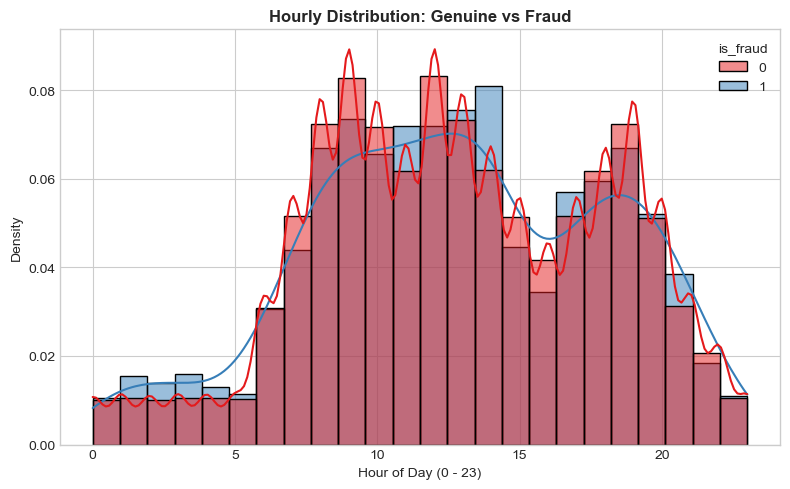

In [11]:
# EDA Data Visualizations
# Hourly Distribution Plot (Graph 1)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('Dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['Amount_log'] = np.log1p(df['amount'])  # Capitalized Amount_log

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='hour', hue='is_fraud', stat='density', common_norm=False, bins=24, palette='Set1', kde=True)
plt.title('Hourly Distribution: Genuine vs Fraud', fontsize=12, fontweight='bold')
plt.xlabel('Hour of Day (0 - 23)', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.tight_layout()
plt.show()

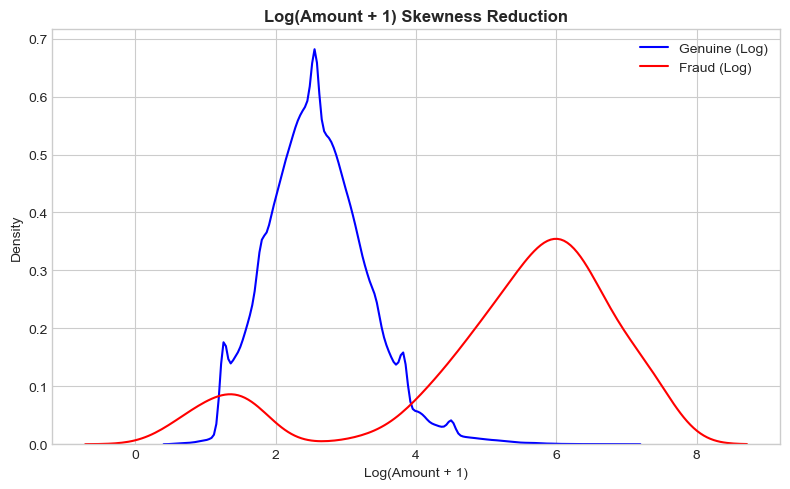

In [13]:
# EDA Data Visualizations
# Log(Amount + 1) Density Plot (Graph 2)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df[df['is_fraud'] == 0]['Amount_log'], label='Genuine (Log)', color='blue')
sns.kdeplot(data=df[df['is_fraud'] == 1]['Amount_log'], label='Fraud (Log)', color='red')
plt.title('Log(Amount + 1) Skewness Reduction', fontsize=12, fontweight='bold')
plt.xlabel('Log(Amount + 1)', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

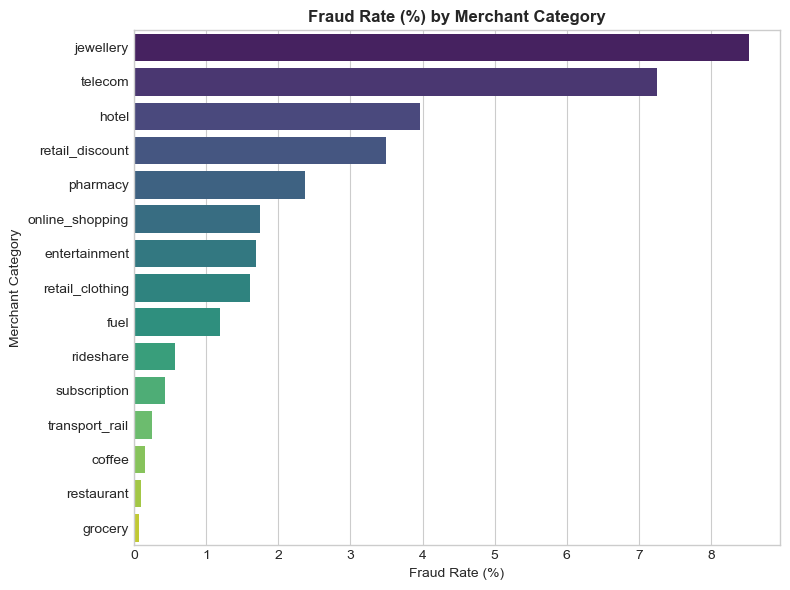

In [14]:
# EDA Data Visualizations

# Fraud Rate by Merchant Category (Graph 3)

plt.figure(figsize=(8, 6))
cat_fraud = df.groupby('merchant_category')['is_fraud'].agg(['count', 'sum'])
cat_fraud['fraud_rate_%'] = (cat_fraud['sum'] / cat_fraud['count']) * 100
cat_fraud = cat_fraud.sort_values(by='fraud_rate_%', ascending=False)

sns.barplot(x=cat_fraud['fraud_rate_%'], y=cat_fraud.index, hue=cat_fraud.index, legend=False, palette='viridis')
plt.title('Fraud Rate (%) by Merchant Category', fontsize=12, fontweight='bold')
plt.xlabel('Fraud Rate (%)', fontsize=10)
plt.ylabel('Merchant Category', fontsize=10)
plt.tight_layout()
plt.show()

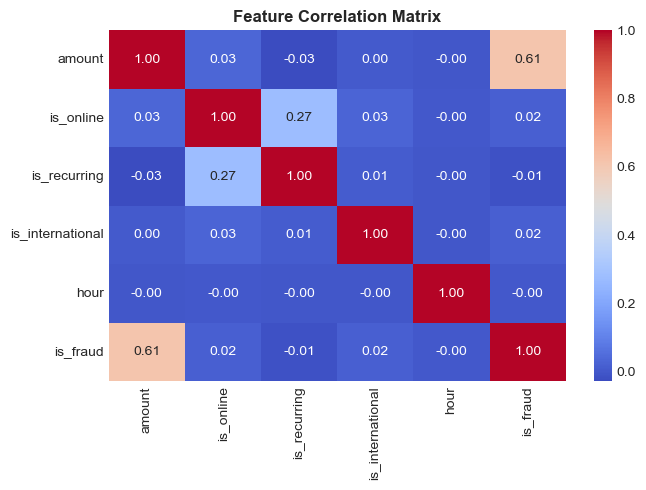

In [16]:
# EDA Data Visualizations
# Feature Correlation Matrix Heatmap (Graph 4)

plt.figure(figsize=(7, 5))

# EDA Only the existing numeric columns have been retained in the stage.
num_cols = ['amount', 'is_online', 'is_recurring', 'is_international', 'hour', 'is_fraud']

# Filtering columns in a DataFrame
num_cols = [col for col in num_cols if col in df.columns]

corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Matrix", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Statistical Significance Test (Mann-Whitney U Test)

from scipy import stats

u_stat_amt, p_val_amt = stats.mannwhitneyu(df[df['is_fraud']==0]['amount'], df[df['is_fraud']==1]['amount'])
u_stat_hr, p_val_hr = stats.mannwhitneyu(df[df['is_fraud']==0]['hour'], df[df['is_fraud']==1]['hour'])

print("--- Statistical Significance Tests (Mann-Whitney U Test) ---")
print(f"Amount Difference P-Value: {p_val_amt:.4e}")
print(f"Hour Difference P-Value:   {p_val_hr:.4e}")

if p_val_amt < 0.05:
    print("→ Result: Transaction amount is statistically different between Fraud and Genuine transactions.")
else:
    print("→ Result: No statistically significant difference in transaction amount.")

if p_val_hr < 0.05:
    print("→ Result: Transaction hour is statistically different between Fraud and Genuine transactions.")
else:
    print("→ Result: No statistically significant difference in transaction hour.")

--- Statistical Significance Tests (Mann-Whitney U Test) ---
Amount Difference P-Value: 0.0000e+00
Hour Difference P-Value:   9.9473e-01
→ Result: Transaction amount is statistically different between Fraud and Genuine transactions.
→ Result: No statistically significant difference in transaction hour.


In [18]:
# Step 2: Feature Engineering & Preprocessing
import numpy as np
import pandas as pd

print(f"--- Data Integrity Pre-check ---")
print(f"Current Data Shape before Feature Engineering: {df.shape}")
if df['transaction_id'].duplicated().sum() > 0:
    print(
        "WARNING: Duplicate Transaction IDs detected! Re-applying drop_duplicates..."
    )
    df = df.drop_duplicates(
        subset=['transaction_id'], keep='first'
    ).reset_index(drop=True)

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.weekday

df['Hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['Hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
df['Weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7.0)
df['Weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7.0)

# Create Amount_log if not created already, then drop raw amount
if 'Amount_log' not in df.columns:
    df['Amount_log'] = np.log1p(df['amount'])

if 'amount' in df.columns:
    df = df.drop(columns=['amount'])

print("\n---Feature Engineering Complete---")
print("Validated Dataset Dimensions:", df.shape)
print("\nFirst 3 Records Audit:")
print(
    df[[
        'timestamp',
        'hour',
        'weekday',
        'Hour_sin',
        'Hour_cos',
        'Weekday_sin',
        'Weekday_cos',
        'Amount_log',
    ]].head(3)
)

--- Data Integrity Pre-check ---
Current Data Shape before Feature Engineering: (500000, 18)

---Feature Engineering Complete---
Validated Dataset Dimensions: (499998, 22)

First 3 Records Audit:
            timestamp  hour  weekday  Hour_sin  Hour_cos  Weekday_sin  \
0 2024-01-01 00:01:43     0        0       0.0       1.0          0.0   
1 2024-01-01 00:01:51     0        0       0.0       1.0          0.0   
2 2024-01-01 00:03:49     0        0       0.0       1.0          0.0   

   Weekday_cos  Amount_log  
0          1.0    2.458734  
1          1.0    3.420346  
2          1.0    2.687847  


In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df_sorted = df.sort_values(by='timestamp').reset_index(drop=True)

y = df_sorted['is_fraud']

time_cols = ['Hour_sin', 'Hour_cos', 'Weekday_sin', 'Weekday_cos']
base_cols = ['Amount_log'] 
feature_cols_with_time = base_cols + time_cols

feature_cols_no_time = base_cols

X_with_time = df_sorted[feature_cols_with_time]
X_no_time = df_sorted[feature_cols_no_time]

n_total = len(df_sorted)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)

X_train_chrono_time = X_with_time.iloc[:n_train].copy()
X_val_chrono_time = X_with_time.iloc[n_train : n_train + n_val].copy()
X_test_chrono_time = X_with_time.iloc[n_train + n_val :].copy()

X_train_chrono_notime = X_no_time.iloc[:n_train].copy()
X_val_chrono_notime = X_no_time.iloc[n_train : n_train + n_val].copy()
X_test_chrono_notime = X_no_time.iloc[n_train + n_val :].copy()

y_train_chrono = y.iloc[:n_train].copy()
y_val_chrono = y.iloc[n_train : n_train + n_val].copy()
y_test_chrono = y.iloc[n_train + n_val :].copy()

X_train_rand_time, X_temp_rand_time, y_train_rand, y_temp_rand = train_test_split(
    X_with_time, y, test_size=0.30, random_state=42, stratify=y
)

X_val_rand_time, X_test_rand_time, y_val_rand, y_test_rand = train_test_split(
    X_temp_rand_time, y_temp_rand, test_size=0.50, random_state=42, stratify=y_temp_rand
)

train_idx, temp_idx = X_train_rand_time.index, X_temp_rand_time.index
val_idx, test_idx = X_val_rand_time.index, X_test_rand_time.index

X_train_rand_notime = X_no_time.loc[train_idx].copy()
X_val_rand_notime = X_no_time.loc[val_idx].copy()
X_test_rand_notime = X_no_time.loc[test_idx].copy()

print("---Splitting Infrastructure---")
print(f"Features WITH Time ({len(feature_cols_with_time)}):", feature_cols_with_time)
print(f"Features WITHOUT Time ({len(feature_cols_no_time)}):", feature_cols_no_time)
print("\nDataset Partition Sizes:")
print(f"Chronological -> Train: {X_train_chrono_time.shape[0]}, Val: {X_val_chrono_time.shape[0]}, Test: {X_test_chrono_time.shape[0]}")
print(f"Stratified Random -> Train: {X_train_rand_time.shape[0]}, Val: {X_val_rand_time.shape[0]}, Test: {X_test_rand_time.shape[0]}")

---Splitting Infrastructure---
Features WITH Time (5): ['Amount_log', 'Hour_sin', 'Hour_cos', 'Weekday_sin', 'Weekday_cos']
Features WITHOUT Time (1): ['Amount_log']

Dataset Partition Sizes:
Chronological -> Train: 349998, Val: 74999, Test: 75001
Stratified Random -> Train: 349998, Val: 75000, Test: 75000


In [20]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler_time = StandardScaler()
scaler_notime = StandardScaler()

X_train_chrono_time_scaled = scaler_time.fit_transform(X_train_chrono_time)
X_val_chrono_time_scaled = scaler_time.transform(X_val_chrono_time)
X_test_chrono_time_scaled = scaler_time.transform(X_test_chrono_time)

X_train_chrono_notime_scaled = scaler_notime.fit_transform(
    X_train_chrono_notime
)
X_val_chrono_notime_scaled = scaler_notime.transform(X_val_chrono_notime)
X_test_chrono_notime_scaled = scaler_notime.transform(X_test_chrono_notime)

scaler_time_rand = StandardScaler()
scaler_notime_rand = StandardScaler()

X_train_rand_time_scaled = scaler_time_rand.fit_transform(X_train_rand_time)
X_val_rand_time_scaled = scaler_time_rand.transform(X_val_rand_time)
X_test_rand_time_scaled = scaler_time_rand.transform(X_test_rand_time)

X_train_rand_notime_scaled = scaler_notime_rand.fit_transform(
    X_train_rand_notime
)
X_val_rand_notime_scaled = scaler_notime_rand.transform(X_val_rand_notime)
X_test_rand_notime_scaled = scaler_notime_rand.transform(X_test_rand_notime)

print("---Feature Scaling---")
print(
    f"Chrono Train Scaled Shape (With Time): {X_train_chrono_time_scaled.shape}"
)
print(
    f"Chrono Train Mean (Feature 0): {X_train_chrono_time_scaled[:, 0].mean():.6f} (Should be ~0)"
)
print(
    f"Chrono Train Std  (Feature 0): {X_train_chrono_time_scaled[:, 0].std():.6f} (Should be ~1)"
)

---Feature Scaling---
Chrono Train Scaled Shape (With Time): (349998, 5)
Chrono Train Mean (Feature 0): 0.000000 (Should be ~0)
Chrono Train Std  (Feature 0): 1.000000 (Should be ~1)


In [21]:
# Step 3: Class Imbalance Handling
import numpy as np
import pandas as pd

n_neg = (y_train_chrono == 0).sum()
n_pos = (y_train_chrono == 1).sum()

scale_pos_weight_ratio = n_neg / n_pos

print("---Class Imbalance---")
print(f"Majority Class (Non-Fraud, y=0) : {n_neg:,}")
print(f"Minority Class (Fraud, y=1)     : {n_pos:,}")
print(
    f"Calculated Imbalance Ratio      : {scale_pos_weight_ratio:.4f} (Negative/Positive)"
)
print("\nLoss Function Penalty Assignment Matrix:")
print(" - Logistic Regression : class_weight='balanced'")
print(" - Random Forest       : class_weight='balanced'")
print(
    f" - XGBoost             : scale_pos_weight={scale_pos_weight_ratio:.4f}"
)

---Class Imbalance---
Majority Class (Non-Fraud, y=0) : 348,595
Minority Class (Fraud, y=1)     : 1,403
Calculated Imbalance Ratio      : 248.4640 (Negative/Positive)

Loss Function Penalty Assignment Matrix:
 - Logistic Regression : class_weight='balanced'
 - Random Forest       : class_weight='balanced'
 - XGBoost             : scale_pos_weight=248.4640


In [22]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [23]:
# Step 4: Model Training
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    roc_auc_score, precision_recall_curve, auc
)


def get_pr_auc(y_true, y_probs):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    return auc(recall, precision)


if 'df' in globals():
    data_df = df.copy()
elif 'data' in globals():
    data_df = data.copy()
else:
    raise ValueError("Main DataFrame ('df' or 'data') not found in environment.")


if 'timestamp' in data_df.columns:
    data_df['timestamp'] = pd.to_datetime(data_df['timestamp'])
    data_df = data_df.sort_values('timestamp').reset_index(drop=True)

target_col = 'is_fraud'
y_all = data_df[target_col]

drop_cols = [target_col, 'transaction_id', 'cardholder_id', 'timestamp', 'fraud_type', 'amount']
all_features = [col for col in data_df.columns if col not in drop_cols]
X_all = data_df[all_features].select_dtypes(include=[np.number]).fillna(0).copy()


X_tr_rand, X_temp, y_tr_rand, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)
X_va_rand, X_te_rand, y_va_rand, y_te_rand = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)


idx_train = int(len(data_df) * 0.70)
idx_val = int(len(data_df) * 0.85)

X_tr_chr, y_tr_chr = X_all.iloc[:idx_train], y_all.iloc[:idx_train]
X_va_chr, y_va_chr = X_all.iloc[idx_train:idx_val], y_all.iloc[idx_train:idx_val]
X_te_chr, y_te_chr = X_all.iloc[idx_val:], y_all.iloc[idx_val:]


cyclic_cols = [c for c in X_all.columns if 'sin' in c.lower() or 'cos' in c.lower()]
non_cyclic_cols = [c for c in X_all.columns if c not in cyclic_cols]

feature_sets = {
    'Without Cyclic': non_cyclic_cols,
    'With Cyclic': list(X_all.columns)
}

splits = {
    'Random Split': (X_tr_rand, y_tr_rand, X_te_rand, y_te_rand),
    'Chronological Split': (X_tr_chr, y_tr_chr, X_te_chr, y_te_chr)
}


results = []
print("Executing Corrected Benchmark Pipeline...\n")

run_id = 1
for split_name, (X_tr, y_tr, X_te, y_te) in splits.items():
    for feat_name, feat_cols in feature_sets.items():
        
        X_tr_sub = X_tr[feat_cols].values
        X_te_sub = X_te[feat_cols].values
        
        # Scaling Setup
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_sub)
        X_te_scaled = scaler.transform(X_te_sub)
        
        models = {
            'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42, C=1.0), True),
            'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1), False),
            'XGBoost': (XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=1, eval_metric='logloss', n_jobs=-1), False)
        }
        
        for model_name, (model, use_scaling) in models.items():
            
            X_tr_eval = X_tr_scaled if use_scaling else X_tr_sub
            X_te_eval = X_te_scaled if use_scaling else X_te_sub
            
            start_train = time.time()
            model.fit(X_tr_eval, y_tr)
            train_time = time.time() - start_train
            
            start_inf = time.time()
            y_probs = model.predict_proba(X_te_eval)[:, 1]
            y_preds = model.predict(X_te_eval)
            inf_time = time.time() - start_inf
            
            prec = precision_score(y_te, y_preds, zero_division=0)
            rec = recall_score(y_te, y_preds, zero_division=0)
            f1 = f1_score(y_te, y_preds, zero_division=0)
            roc_auc = roc_auc_score(y_te, y_probs)
            pr_auc = get_pr_auc(y_te, y_probs)
            
            results.append({
                'Run': run_id,
                'Split Type': split_name,
                'Feature Set': feat_name,
                'Model': model_name,
                'Precision': round(prec, 4),
                'Recall': round(rec, 4),
                'F1-Score': round(f1, 4),
                'ROC-AUC': round(roc_auc, 4),
                'PR-AUC': round(pr_auc, 4),
                'Train Time (s)': round(train_time, 3),
                'Inference Time (s)': round(inf_time, 3)
            })
            
            print(f"Run {run_id}/12 Complete: [{split_name} | {feat_name} | {model_name}]")
            run_id += 1

df_results = pd.DataFrame(results)
print("\n Execution Completed Successfully!")
df_results

Executing Corrected Benchmark Pipeline...

Run 1/12 Complete: [Random Split | Without Cyclic | Logistic Regression]
Run 2/12 Complete: [Random Split | Without Cyclic | Random Forest]
Run 3/12 Complete: [Random Split | Without Cyclic | XGBoost]
Run 4/12 Complete: [Random Split | With Cyclic | Logistic Regression]
Run 5/12 Complete: [Random Split | With Cyclic | Random Forest]
Run 6/12 Complete: [Random Split | With Cyclic | XGBoost]
Run 7/12 Complete: [Chronological Split | Without Cyclic | Logistic Regression]
Run 8/12 Complete: [Chronological Split | Without Cyclic | Random Forest]
Run 9/12 Complete: [Chronological Split | Without Cyclic | XGBoost]
Run 10/12 Complete: [Chronological Split | With Cyclic | Logistic Regression]
Run 11/12 Complete: [Chronological Split | With Cyclic | Random Forest]
Run 12/12 Complete: [Chronological Split | With Cyclic | XGBoost]

 Execution Completed Successfully!


,Run,Split Type,Feature Set,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Train Time (s),Inference Time (s)
0,1,Random Split,Without Cyclic,Logistic Regression,0.9507,0.4313,0.5934,0.8756,0.6956,0.262,0.005
1,2,Random Split,Without Cyclic,Random Forest,0.9672,0.7540,0.8474,0.9475,0.8523,11.991,0.208
2,3,Random Split,Without Cyclic,XGBoost,0.9127,0.7348,0.8142,0.9913,0.8404,1.136,0.071
3,4,Random Split,With Cyclic,Logistic Regression,0.9441,0.4313,0.5921,0.8757,0.6952,0.241,0.005
4,5,Random Split,With Cyclic,Random Forest,0.8858,0.6198,0.7293,0.9488,0.8012,12.976,0.294
5,6,Random Split,With Cyclic,XGBoost,0.8962,0.7444,0.8133,0.9888,0.8387,1.367,0.071
6,7,Chronological Split,Without Cyclic,Logistic Regression,0.9315,0.5787,0.7139,0.8748,0.7386,0.260,0.004
7,8,Chronological Split,Without Cyclic,Random Forest,0.9223,0.8085,0.8617,0.9523,0.8765,9.529,0.205
8,9,Chronological Split,Without Cyclic,XGBoost,0.8706,0.7447,0.8028,0.9854,0.8437,1.371,0.053
9,10,Chronological Split,With Cyclic,Logistic Regression,0.9320,0.5830,0.7173,0.8750,0.7387,0.252,0.006


In [24]:
# Step 5: Model Evaluation, Comparative Analysis & Explainability (SHAP)
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

best_thresholds = []

val_splits = {
    'Random Split': (X_tr_rand, y_tr_rand, X_va_rand, y_va_rand, X_te_rand, y_te_rand),
    'Chronological Split': (X_tr_chr, y_tr_chr, X_va_chr, y_va_chr, X_te_chr, y_te_chr)
}

print("Optimizing Classification Thresholds on 15% Validation Sets...\n")

for split_name, (X_tr, y_tr, X_va, y_va, X_te, y_te) in val_splits.items():
    for feat_name, feat_cols in feature_sets.items():
        
        X_tr_sub = X_tr[feat_cols].values
        X_va_sub = X_va[feat_cols].values
        X_te_sub = X_te[feat_cols].values
        
        model = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=1, eval_metric='logloss', n_jobs=-1)
        model.fit(X_tr_sub, y_tr)
        
        y_val_probs = model.predict_proba(X_va_sub)[:, 1]
        
        thresholds = np.linspace(0.1, 0.9, 81)
        best_f1_val = 0.0
        opt_thresh = 0.5
        
        for t in thresholds:
            val_preds = (y_val_probs >= t).astype(int)
            score = f1_score(y_va, val_preds, zero_division=0)
            if score > best_f1_val:
                best_f1_val = score
                opt_thresh = t
                
        y_test_probs = model.predict_proba(X_te_sub)[:, 1]
        
        def_preds = (y_test_probs >= 0.5).astype(int)
        def_f1 = f1_score(y_te, def_preds, zero_division=0)
        
        opt_preds = (y_test_probs >= opt_thresh).astype(int)
        opt_prec = precision_score(y_te, opt_preds, zero_division=0)
        opt_rec = recall_score(y_te, opt_preds, zero_division=0)
        opt_f1 = f1_score(y_te, opt_preds, zero_division=0)
        
        best_thresholds.append({
            'Split Strategy': split_name,
            'Feature Set': feat_name,
            'Optimal Threshold': round(opt_thresh, 3),
            'Default F1 (0.5)': round(def_f1, 4),
            'Tuned F1 (Test)': round(opt_f1, 4),
            'Tuned Precision': round(opt_prec, 4),
            'Tuned Recall': round(opt_rec, 4)
        })

df_thresholds = pd.DataFrame(best_thresholds)
print("Validation Threshold Optimization Completed Successfully!")
df_thresholds

Optimizing Classification Thresholds on 15% Validation Sets...

Validation Threshold Optimization Completed Successfully!


,Split Strategy,Feature Set,Optimal Threshold,Default F1 (0.5),Tuned F1 (Test),Tuned Precision,Tuned Recall
0,Random Split,Without Cyclic,0.33,0.8142,0.8128,0.8607,0.7700
1,Random Split,With Cyclic,0.29,0.8133,0.8147,0.8531,0.7796
2,Chronological Split,Without Cyclic,0.33,0.8028,0.7897,0.7965,0.7830
3,Chronological Split,With Cyclic,0.27,0.7926,0.7666,0.7716,0.7617


In [25]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [26]:
# Feature Audit Check for SHAP
print("--- Final Feature Set Audit for SHAP Explanation ---")
print("Features active in model pipeline:", feature_sets['Without Cyclic'])

if 'Amount_log' in feature_sets['Without Cyclic']:
    print("SUCCESS: 'Amount_log' is correctly included.")
else:
    print("WARNING: 'Amount_log' missing from feature list.")

if 'amount' not in feature_sets['Without Cyclic']:
    print("SUCCESS: Raw 'amount' column correctly removed.")
else:
    print("WARNING: Raw 'amount' is still present.")

--- Final Feature Set Audit for SHAP Explanation ---
Features active in model pipeline: ['mcc', 'hour', 'Amount_log', 'weekday']
SUCCESS: 'Amount_log' is correctly included.
SUCCESS: Raw 'amount' column correctly removed.


Generating SHAP Explanations for the Best Performing Model...



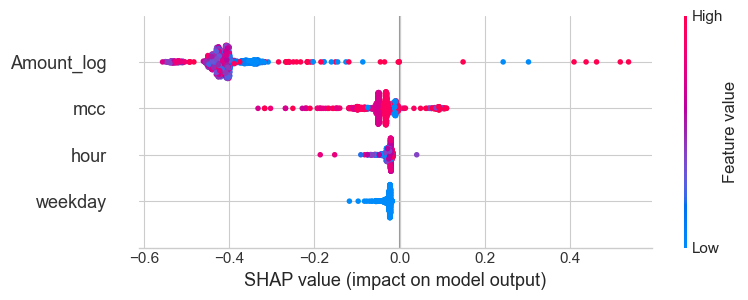

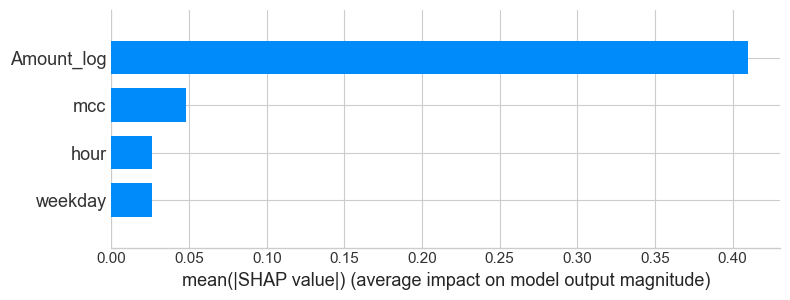

In [27]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

print("Generating SHAP Explanations for the Best Performing Model...\n")

best_feat_cols = feature_sets['Without Cyclic']
X_tr_shap = X_tr_chr[best_feat_cols]
X_te_shap = X_te_chr[best_feat_cols]

rf_shap_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_shap_model.fit(X_tr_shap, y_tr_chr)

sample_size = min(1000, len(X_te_shap))
X_te_sample = X_te_shap.iloc[:sample_size]

explainer = shap.TreeExplainer(rf_shap_model)
shap_values = explainer.shap_values(X_te_sample)

if isinstance(shap_values, list):
    shap_vals_fraud = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_vals_fraud = shap_values[:, :, 1]
else:
    shap_vals_fraud = shap_values

plt.close('all')
shap.summary_plot(shap_vals_fraud, X_te_sample, plot_type="dot", show=True)

plt.close('all')
shap.summary_plot(shap_vals_fraud, X_te_sample, plot_type="bar", show=True)

Executing Final Evaluation on Hold-out Test Set...

FINAL TEST SET RESULTS (Threshold = 0.33)
Final Precision : 0.8761
Final Recall    : 0.8426
Final F1-Score  : 0.8590

Classification Report:

              precision    recall  f1-score   support

  Normal (0)     0.9995    0.9996    0.9996     74765
   Fraud (1)     0.8761    0.8426    0.8590       235

    accuracy                         0.9991     75000
   macro avg     0.9378    0.9211    0.9293     75000
weighted avg     0.9991    0.9991    0.9991     75000



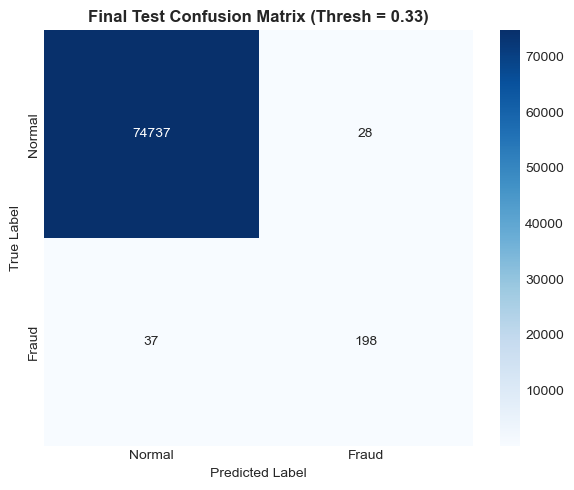

In [28]:
# Step 6: Model Testing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

print("Executing Final Evaluation on Hold-out Test Set...\n")

best_features = feature_sets['Without Cyclic']

X_tr_final = X_tr_chr[best_features]
y_tr_final = y_tr_chr

X_te_final = X_te_chr[best_features]
y_te_final = y_te_chr

optimal_thresh = 0.33 

rf_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_final.fit(X_tr_final, y_tr_final)

y_test_probs = rf_final.predict_proba(X_te_final)[:, 1]
y_test_preds = (y_test_probs >= optimal_thresh).astype(int)

prec, rec, f1, _ = precision_recall_fscore_support(y_te_final, y_test_preds, average='binary')

print("="*50)
print(f"FINAL TEST SET RESULTS (Threshold = {optimal_thresh})")
print("="*50)
print(f"Final Precision : {prec:.4f}")
print(f"Final Recall    : {rec:.4f}")
print(f"Final F1-Score  : {f1:.4f}")
print("="*50)

print("\nClassification Report:\n")
print(classification_report(y_te_final, y_test_preds, target_names=['Normal (0)', 'Fraud (1)'], digits=4))

cm = confusion_matrix(y_te_final, y_test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title(f'Final Test Confusion Matrix (Thresh = {optimal_thresh})', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()